In [ ]:
!unzip "/content/drive/MyDrive/TumorSegmentasyon/data.zip" -d "/content/"

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/data/train/labels/Papiloma_T1C+_7.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_70.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_71.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_73.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_74.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_76.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_77.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_79.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_8.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_80.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_81.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_82.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_83.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_85.txt  
  inflating: /content/data/train/labels/Papiloma_T1C+_86.txt  
  inflatin

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import *
from tensorflow.keras.metrics import Precision, Recall

In [ ]:
train_images = []
train_masks = []
train_masks_temp = []
val_images = []
val_masks = []
val_masks_temp = []
test_images = []
test_masks = []
test_masks_temp = []

path = "/content/data/train/images/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    train_images.append(path + fileName)

path = "/content/data/train/masks/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    train_masks_temp.append(path + fileName)

path = "/content/data/val/images/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    val_images.append(path + fileName)

path = "/content/data/val/masks/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    val_masks_temp.append(path + fileName)

path = "/content/data/test/images/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    test_images.append(path + fileName)

path = "/content/data/test/masks/"
tarama=os.scandir(path)
for belge in tarama:
    fileName = belge.name
    test_masks_temp.append(path + fileName)

In [ ]:
print(len(train_images))
print(len(train_masks))
print(len(train_masks_temp))
print(len(val_images))
print(len(val_masks))
print(len(val_masks_temp))
print(len(test_images))
print(len(test_masks))
print(len(test_masks_temp))

3160
0
3160
405
0
405
391
0
391


In [ ]:
for imagePath in train_images:
    for maskPath in train_masks_temp:
        imageName = imagePath.split("/")[-1].split(".")[0]
        maskName = maskPath.split("/")[-1].split(".")[0][:-5]
        if (imageName == maskName):
            train_masks.append(maskPath)
            break

for imagePath in val_images:
    for maskPath in val_masks_temp:
        imageName = imagePath.split("/")[-1].split(".")[0]
        maskName = maskPath.split("/")[-1].split(".")[0][:-5]
        if (imageName == maskName):
            val_masks.append(maskPath)
            break

for imagePath in test_images:
    for maskPath in test_masks_temp:
        imageName = imagePath.split("/")[-1].split(".")[0]
        maskName = maskPath.split("/")[-1].split(".")[0][:-5]
        if (imageName == maskName):
            test_masks.append(maskPath)
            break

In [ ]:
print(len(train_images))
print(len(train_masks))
print(len(train_masks_temp))
print(len(val_images))
print(len(val_masks))
print(len(val_masks_temp))
print(len(test_images))
print(len(test_masks))
print(len(test_masks_temp))

3160
3160
3160
405
405
405
391
391
391


In [ ]:
print(train_images[0], train_masks[0])
print(val_images[0], val_masks[0])
print(test_images[0], test_masks[0])

/content/data/train/images/Neurocitoma_T2_71.jpeg /content/data/train/masks/Neurocitoma_T2_71_mask.jpg
/content/data/val/images/Astrocitoma_T1_112.jpeg /content/data/val/masks/Astrocitoma_T1_112_mask.jpg
/content/data/test/images/Meningioma_T1C+_10.jpeg /content/data/test/masks/Meningioma_T1C+_10_mask.jpg


In [ ]:
def get_df(image_paths, mask_paths):
    pd_df = pd.DataFrame({
        'image_paths' : image_paths,
        'mask_paths' : mask_paths
    })
    return pd_df

In [ ]:
train_df = get_df(train_images, train_masks)
val_df = get_df(val_images, val_masks)
test_df = get_df(test_images, test_masks)

In [ ]:
train_df

,image_paths,mask_paths
0,/content/data/train/images/Neurocitoma_T2_71.jpeg,/content/data/train/masks/Neurocitoma_T2_71_ma...
1,/content/data/train/images/Tuberculoma_T1C+_66...,/content/data/train/masks/Tuberculoma_T1C+_66_...
2,/content/data/train/images/Oligodendroglioma_T...,/content/data/train/masks/Oligodendroglioma_T1...
3,/content/data/train/images/Oligodendroglioma_T...,/content/data/train/masks/Oligodendroglioma_T1...
4,/content/data/train/images/Meningioma_T2_18.jpg,/content/data/train/masks/Meningioma_T2_18_mas...
...,...,...
3155,/content/data/train/images/Granuloma_T1C+_7.jpeg,/content/data/train/masks/Granuloma_T1C+_7_mas...
3156,/content/data/train/images/Glioblastoma_T1_37....,/content/data/train/masks/Glioblastoma_T1_37_m...
3157,/content/data/train/images/Neurocitoma_T1C+_21...,/content/data/train/masks/Neurocitoma_T1C+_212...
3158,/content/data/train/images/Meningioma_T2_90.jpg,/content/data/train/masks/Meningioma_T2_90_mas...


In [ ]:
val_df

,image_paths,mask_paths
0,/content/data/val/images/Astrocitoma_T1_112.jpeg,/content/data/val/masks/Astrocitoma_T1_112_mas...
1,/content/data/val/images/Meningioma_T1C+_245.jpeg,/content/data/val/masks/Meningioma_T1C+_245_ma...
2,/content/data/val/images/Oligodendroglioma_T2_...,/content/data/val/masks/Oligodendroglioma_T2_4...
3,/content/data/val/images/Ependimoma_T2_7.jpg,/content/data/val/masks/Ependimoma_T2_7_mask.jpg
4,/content/data/val/images/Papiloma_T1C+_72.jpg,/content/data/val/masks/Papiloma_T1C+_72_mask.jpg
...,...,...
400,/content/data/val/images/Neurocitoma_T2_77.jpeg,/content/data/val/masks/Neurocitoma_T2_77_mask...
401,/content/data/val/images/Meningioma_T2_191.jpeg,/content/data/val/masks/Meningioma_T2_191_mask...
402,/content/data/val/images/Oligodendroglioma_T1C...,/content/data/val/masks/Oligodendroglioma_T1C+...
403,/content/data/val/images/Neurocitoma_T1_89.jpeg,/content/data/val/masks/Neurocitoma_T1_89_mask...


In [ ]:
test_df

,image_paths,mask_paths
0,/content/data/test/images/Meningioma_T1C+_10.jpeg,/content/data/test/masks/Meningioma_T1C+_10_ma...
1,/content/data/test/images/Schwannoma_T1C+_79.jpeg,/content/data/test/masks/Schwannoma_T1C+_79_ma...
2,/content/data/test/images/Meningioma_T2_227.jpeg,/content/data/test/masks/Meningioma_T2_227_mas...
3,/content/data/test/images/Oligodendroglioma_T1...,/content/data/test/masks/Oligodendroglioma_T1_...
4,/content/data/test/images/Papiloma_T1C+_12.jpg,/content/data/test/masks/Papiloma_T1C+_12_mask...
...,...,...
386,/content/data/test/images/Meningioma_T1C+_276....,/content/data/test/masks/Meningioma_T1C+_276_m...
387,/content/data/test/images/Meduloblastoma_T1_5....,/content/data/test/masks/Meduloblastoma_T1_5_m...
388,/content/data/test/images/Meduloblastoma_T1_10...,/content/data/test/masks/Meduloblastoma_T1_10_...
389,/content/data/test/images/Meningioma_T1C+_306....,/content/data/test/masks/Meningioma_T1C+_306_m...


In [ ]:
img_size = (256, 256)
batch_size = 32

In [ ]:
def set_generator(data_frame, batch_size, aug_dict, target_size,
                    image_color_mode="rgb",
                    mask_color_mode="grayscale",
                    image_save_prefix="image",
                    mask_save_prefix="mask",
                    save_to_dir=None,
                    seed=1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow_from_dataframe(
        data_frame,
        x_col = "image_paths",
        class_mode = None,
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = image_save_prefix,
        seed = seed)

    mask_generator = mask_datagen.flow_from_dataframe(
        data_frame,
        x_col = "mask_paths",
        class_mode = None,
        color_mode = mask_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = mask_save_prefix,
        seed = seed)

    train_gen = zip(image_generator, mask_generator)

    for (img, mask) in train_gen:
        img, mask = adjust_data(img, mask)
        yield (img,mask)

def adjust_data(img,mask):
    img = img / 255.
    mask = mask / 255.
    mask[mask > 0.5] = 1
    mask[mask <= 0.5] = 0

    return (img, mask)

In [ ]:
train_gen = set_generator(train_df, batch_size, dict(), img_size)

val_gen = set_generator(val_df, batch_size, dict(), img_size)

test_gen = set_generator(test_df, batch_size, dict(), img_size)

In [ ]:
input_shape = (256,256,3)

def resblock(X, f):
    '''
    function for creating res block
    '''
    X_copy = X  #copy of input

    # main path
    X = Conv2D(f, kernel_size=(1,1), kernel_initializer='he_normal')(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)

    X = Conv2D(f, kernel_size=(3,3), padding='same', kernel_initializer='he_normal')(X)
    X = BatchNormalization()(X)

    # shortcut path
    X_copy = Conv2D(f, kernel_size=(1,1), kernel_initializer='he_normal')(X_copy)
    X_copy = BatchNormalization()(X_copy)

    # Adding the output from main path and short path together
    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    return X

def upsample_concat(x, skip):
    '''
    funtion for upsampling image
    '''
    X = UpSampling2D((2,2))(x)
    merge = Concatenate()([X, skip])

    return merge

def create_model():
    X_input = Input(input_shape) #iniating tensor of input shape

    # Stage 1
    conv_1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(X_input)
    conv_1 = BatchNormalization()(conv_1)
    conv_1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv_1)
    conv_1 = BatchNormalization()(conv_1)
    pool_1 = MaxPool2D((2,2))(conv_1)

    # stage 2
    conv_2 = resblock(pool_1, 32)
    pool_2 = MaxPool2D((2,2))(conv_2)

    # Stage 3
    conv_3 = resblock(pool_2, 64)
    pool_3 = MaxPool2D((2,2))(conv_3)

    # Stage 4
    conv_4 = resblock(pool_3, 128)
    pool_4 = MaxPool2D((2,2))(conv_4)

    # Stage 5 (bottle neck)
    conv_5 = resblock(pool_4, 256)

    # Upsample Stage 1
    up_1 = upsample_concat(conv_5, conv_4)
    up_1 = resblock(up_1, 128)

    # Upsample Stage 2
    up_2 = upsample_concat(up_1, conv_3)
    up_2 = resblock(up_2, 64)

    # Upsample Stage 3
    up_3 = upsample_concat(up_2, conv_2)
    up_3 = resblock(up_3, 32)

    # Upsample Stage 4
    up_4 = upsample_concat(up_3, conv_1)
    up_4 = resblock(up_4, 16)

    # final output
    out = Conv2D(1, (1,1), kernel_initializer='he_normal', padding='same', activation='sigmoid')(up_4)

    seg_model = Model(X_input, out)

    return seg_model

In [ ]:
def dice_coef(y_true, y_pred, smooth=100):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)

    intersection = K.sum(y_true_flatten * y_pred_flatten)
    union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
    return (2.0 * intersection + smooth) / (union + smooth)

def iou_coef(y_true, y_pred, smooth=100):
    intersection = K.sum(y_true * y_pred)
    sum = K.sum(y_true + y_pred)
    iou = (intersection + smooth) / (sum - intersection + smooth)
    return iou

def dice_coef_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()
    return dice_coef_loss(y_true, y_pred) + bce(y_true, y_pred)

In [ ]:
model = create_model()

model.compile(optimizer=Adamax(learning_rate=0.001), loss=bce_dice_loss, metrics=['accuracy', Precision(), Recall(), dice_coef, iou_coef])

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 16)         448       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 16)         64        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 conv2d_1 (Conv2D)           (None, 256, 256, 16)         2320      ['batch_normalization[0][0

In [ ]:
file_path = "Clean-ResUNet-Adamax-32-bce-dice.h5"
save_path = "/content/" + file_path
drive_path = "/content/drive/MyDrive/TumorSegmentasyon/" + file_path

In [ ]:
checkpoint = ModelCheckpoint(save_path,
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=False,
                             mode='min',
                             verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.1,
                              patience=3,
                              mode='min',
                              min_lr=0.0001,
                              verbose= 1)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           mode='min',
                           restore_best_weights=True,
                           verbose=1)

history = model.fit(train_gen,
                    epochs= 100,
                    callbacks=[early_stop, checkpoint, reduce_lr],
                    validation_data= val_gen,
                    steps_per_epoch=len(train_df) / batch_size,
                    validation_steps=len(val_df) / batch_size)

Found 3160 validated image filenames.
Found 3160 validated image filenames.
Epoch 1/100
99/98 [==============================] - ETA: 0s - loss: 1.4381 - accuracy: 0.8385 - precision: 0.0687 - recall: 0.4082 - dice_coef: 0.0698 - iou_coef: 0.0363Found 405 validated image filenames.
Found 405 validated image filenames.

Epoch 1: val_loss improved from inf to 1.90726, saving model to /content/Clean-ResUNet-Adamax-32-bce-dice.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


98/98 [==============================] - 69s 438ms/step - loss: 1.4381 - accuracy: 0.8385 - precision: 0.0687 - recall: 0.4082 - dice_coef: 0.0698 - iou_coef: 0.0363 - val_loss: 1.9073 - val_accuracy: 0.4928 - val_precision: 0.0484 - val_recall: 0.9883 - val_dice_coef: 0.0730 - val_iou_coef: 0.0379 - lr: 0.0010
Epoch 2/100
99/98 [==============================] - ETA: 0s - loss: 1.1062 - accuracy: 0.9651 - precision: 0.3707 - recall: 0.4602 - dice_coef: 0.1273 - iou_coef: 0.0684
Epoch 2: val_loss improved from 1.90726 to 1.53625, saving model to /content/Clean-ResUNet-Adamax-32-bce-dice.h5
98/98 [==============================] - 36s 361ms/step - loss: 1.1062 - accuracy: 0.9651 - precision: 0.3707 - recall: 0.4602 - dice_coef: 0.1273 - iou_coef: 0.0684 - val_loss: 1.5363 - val_accuracy: 0.7050 - val_precision: 0.0687 - val_recall: 0.8419 - val_dice_coef: 0.0998 - val_iou_coef: 0.0526 - lr: 0.0010
Epoch 3/100
99/98 [==============================] - ETA: 0s - loss: 0.9370 - accuracy: 0.

In [ ]:
def plot_training(hist):
    '''
    This function take training model and plot history of accuracy and losses with the best epoch in both of them.
    '''

    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_iou = hist.history['iou_coef']
    tr_dice = hist.history['dice_coef']
    tr_loss = hist.history['loss']

    val_acc = hist.history['val_accuracy']
    val_iou = hist.history['val_iou_coef']
    val_dice = hist.history['val_dice_coef']
    val_loss = hist.history['val_loss']

    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    index_iou = np.argmax(iou_coef)
    iou_highest = val_iou[index_iou]
    index_dice = np.argmax(dice_coef)
    dice_highest = val_dice[index_dice]
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]

    Epochs = [i+1 for i in range(len(tr_acc))]

    acc_label = f'best epoch= {str(index_acc + 1)}'
    iou_label = f'best epoch= {str(index_iou + 1)}'
    dice_label = f'best epoch= {str(index_dice + 1)}'
    loss_label = f'best epoch= {str(index_loss + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 20))
    plt.style.use('fivethirtyeight')

    # Training Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Training IoU
    plt.subplot(2, 2, 2)
    plt.plot(Epochs, tr_iou, 'r', label= 'Training IoU')
    plt.plot(Epochs, val_iou, 'g', label= 'Validation IoU')
    plt.scatter(index_iou + 1 , iou_highest, s= 150, c= 'blue', label= iou_label)
    plt.title('Training and Validation IoU Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    # Training Dice
    plt.subplot(2, 2, 3)
    plt.plot(Epochs, tr_dice, 'r', label= 'Training Dice')
    plt.plot(Epochs, val_dice, 'g', label= 'Validation Dice')
    plt.scatter(index_dice + 1 , dice_highest, s= 150, c= 'blue', label= dice_label)
    plt.title('Training and Validation Dice Coefficient')
    plt.xlabel('Epochs')
    plt.ylabel('Dice')
    plt.legend()

    # Training Loss
    plt.subplot(2, 2, 4)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout
    plt.show()

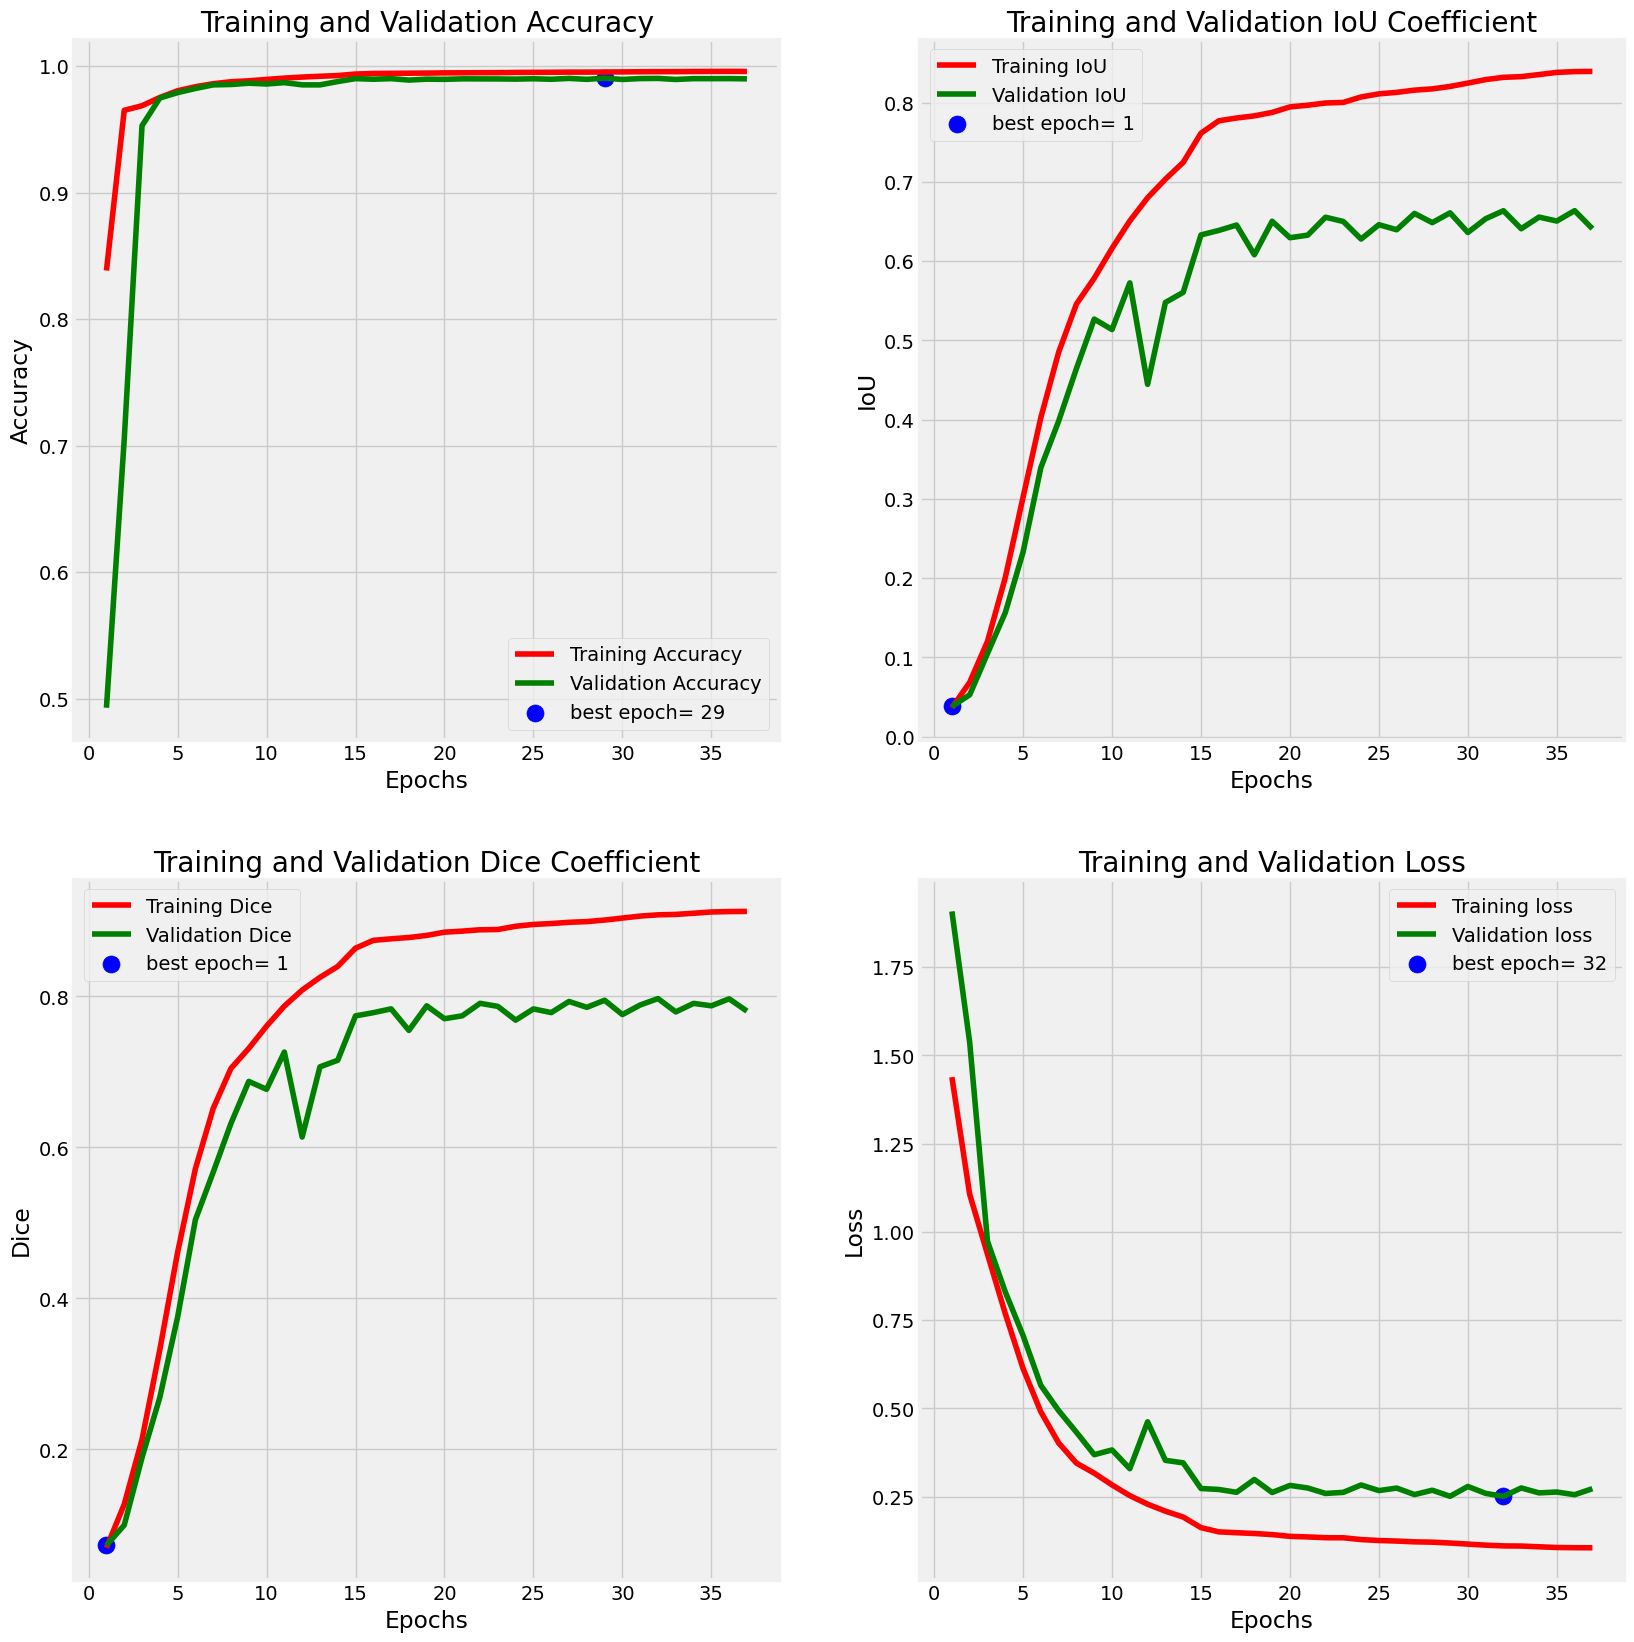

In [ ]:
plot_training(history)

In [ ]:
print(model.metrics_names)

['loss', 'accuracy', 'precision', 'recall', 'dice_coef', 'iou_coef']


In [ ]:
train_score = model.evaluate(train_gen, steps= len(train_df) / batch_size, verbose= 1)
valid_score = model.evaluate(val_gen, steps= len(val_df) / batch_size, verbose= 1)
test_score = model.evaluate(test_gen, steps= len(test_df) / batch_size, verbose= 1)


print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print("Train Precision: ", train_score[2])
print("Train Recall: ", train_score[3])
print("Train Dice: ", train_score[4])
print("Train IoU: ", train_score[5])
print('-' * 20)

print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print("Valid Precision: ", valid_score[2])
print("Valid Recall: ", valid_score[3])
print("Valid Dice: ", valid_score[4])
print("Valid IoU: ", valid_score[5])
print('-' * 20)

print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])
print("Test Precision: ", test_score[2])
print("Test Recall: ", test_score[3])
print("Test Dice: ", test_score[4])
print("Test IoU: ", test_score[5])

12/12 [==============================] - 2s 157ms/step - loss: 0.2646 - accuracy: 0.9900 - precision: 0.8425 - recall: 0.7586 - dice_coef: 0.7884 - iou_coef: 0.6533
Found 391 validated image filenames.
Found 391 validated image filenames.
12/12 [==============================] - 3s 244ms/step - loss: 0.2652 - accuracy: 0.9900 - precision: 0.8606 - recall: 0.7423 - dice_coef: 0.7929 - iou_coef: 0.6600
Train Loss:  0.10255656391382217
Train Accuracy:  0.9960864782333374
Train Precision:  0.9341252446174622
Train Recall:  0.9149224162101746
Train Dice:  0.9147125482559204
Train IoU:  0.8433804512023926
--------------------
Valid Loss:  0.26460328698158264
Valid Accuracy:  0.9900007843971252
Valid Precision:  0.8424772024154663
Valid Recall:  0.7585639357566833
Valid Dice:  0.7884470820426941
Valid IoU:  0.6532859802246094
--------------------
Test Loss:  0.26515838503837585
Test Accuracy:  0.9899908304214478
Test Precision:  0.8606347441673279
Test Recall:  0.742268443107605
Test Dice:  0

Validation Images


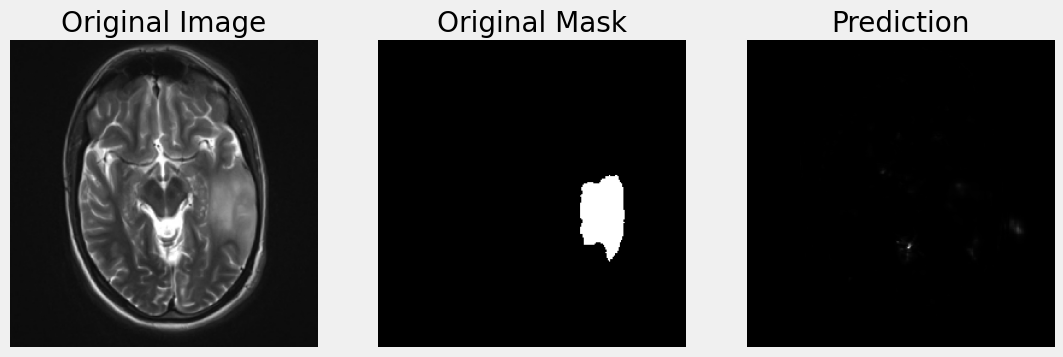

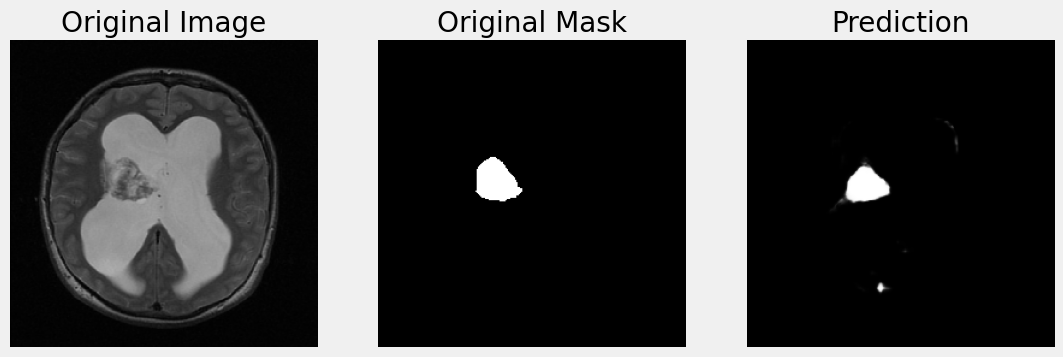

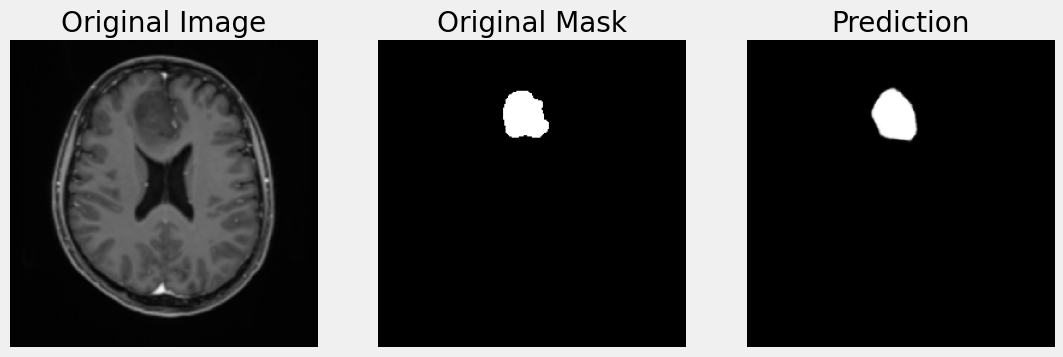

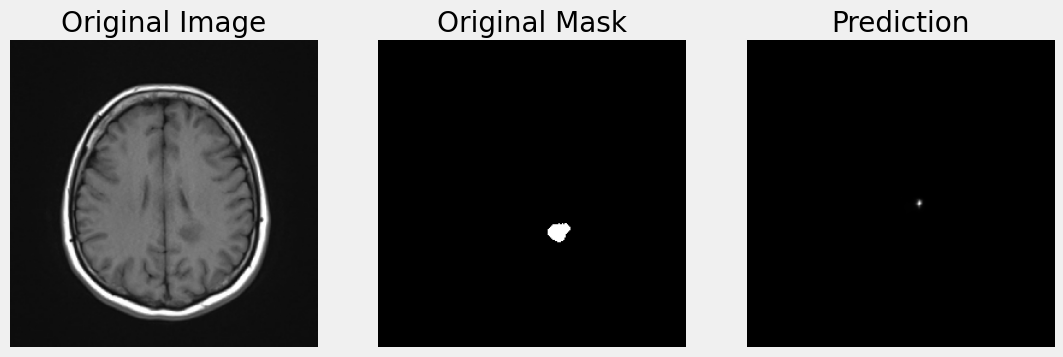

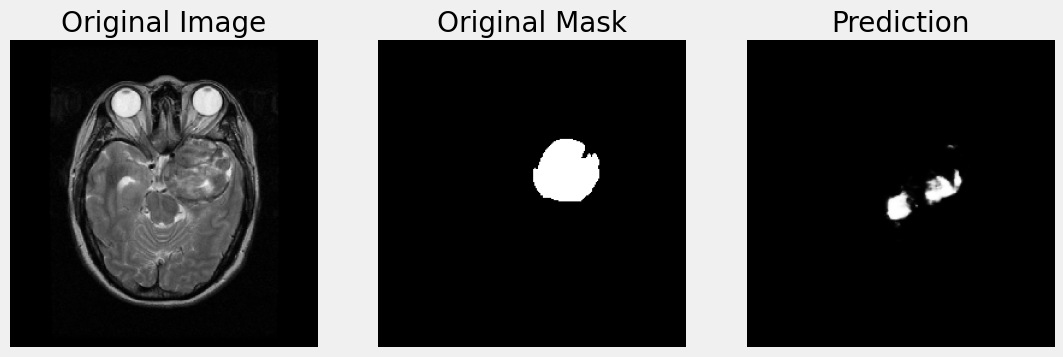

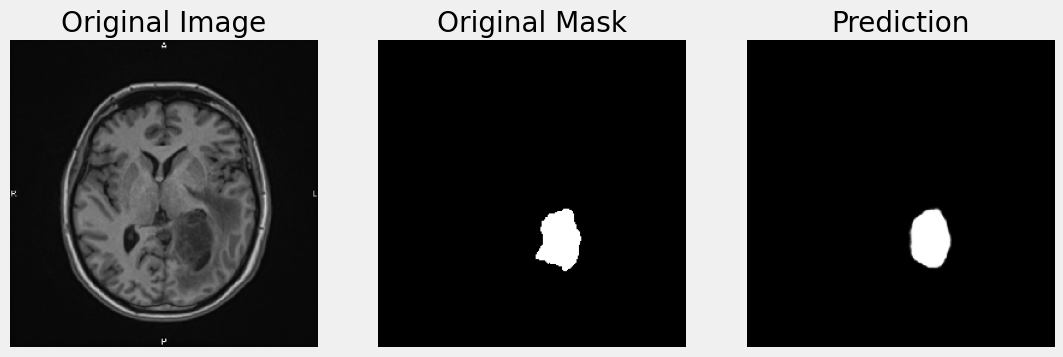

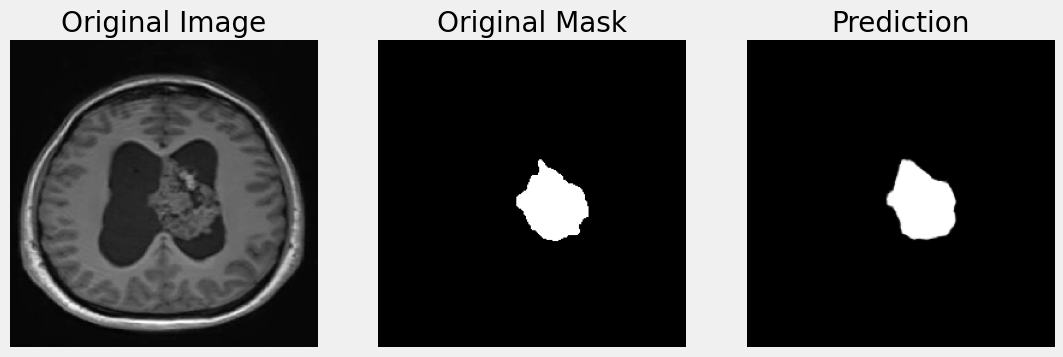

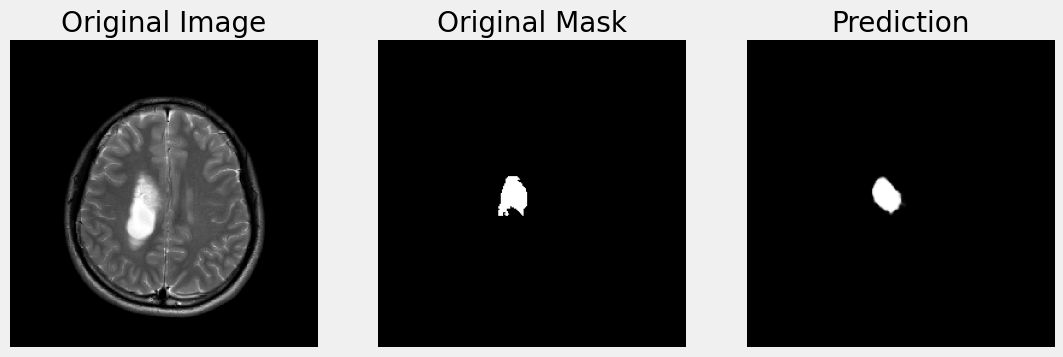

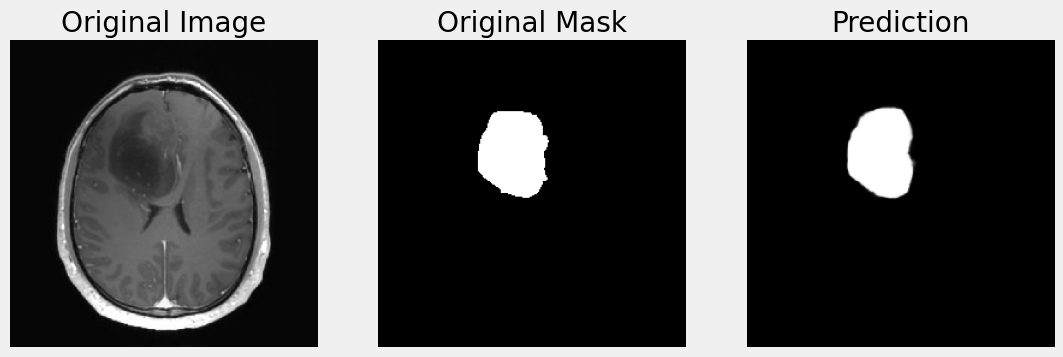

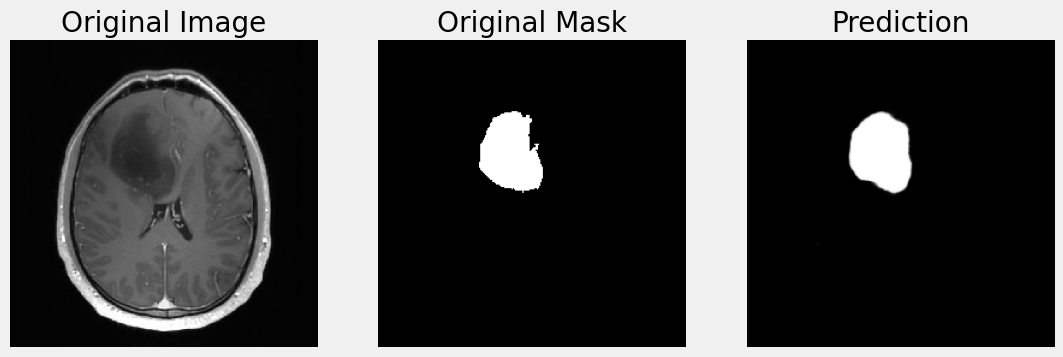

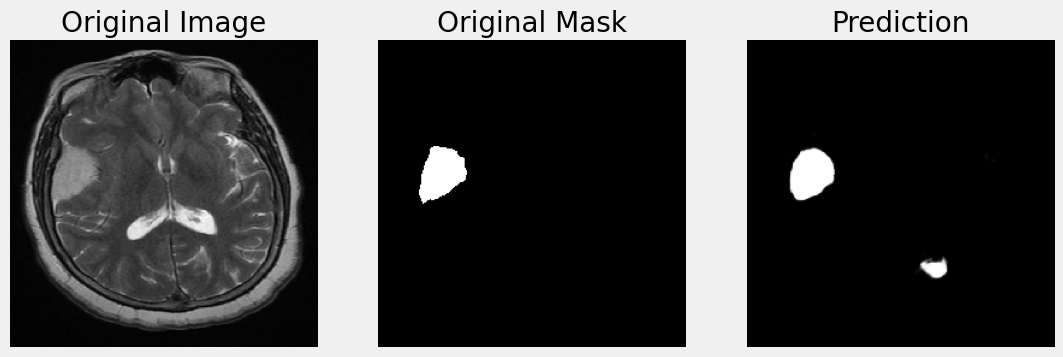

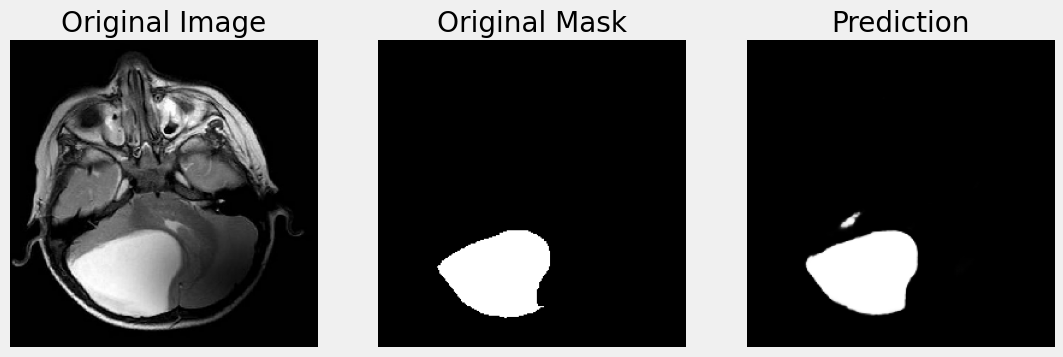

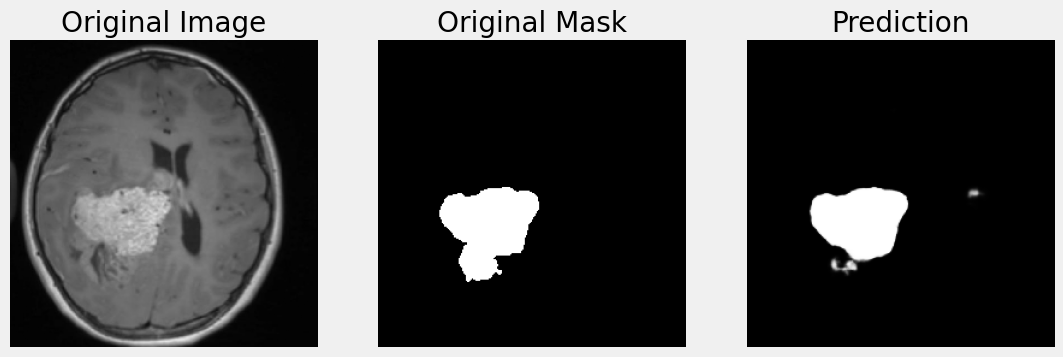

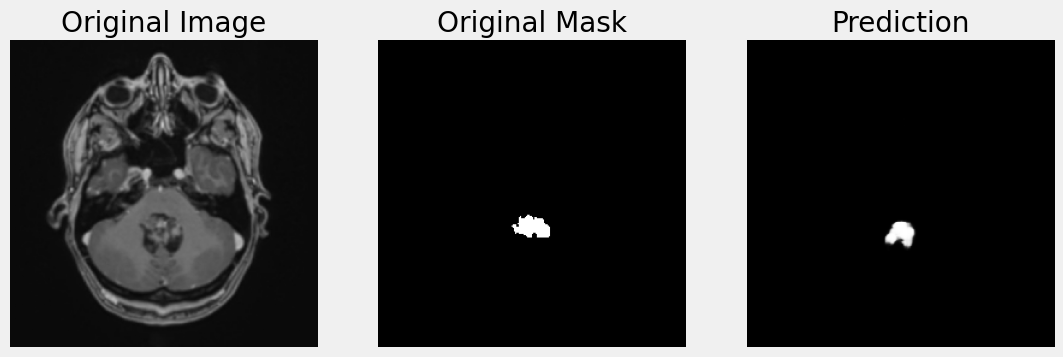

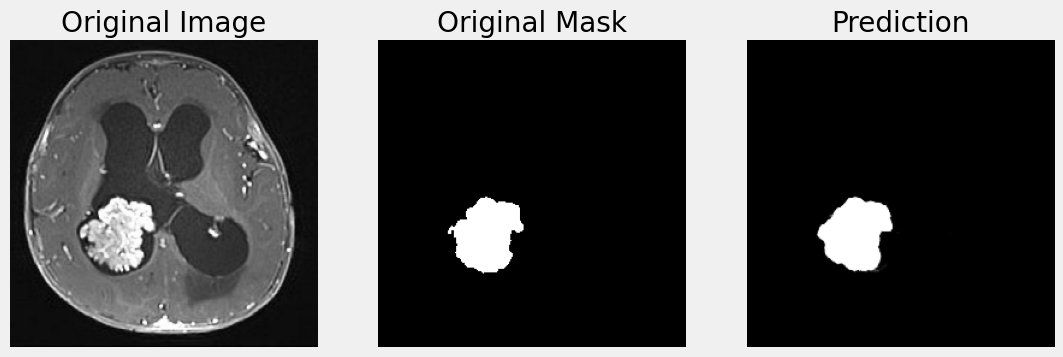

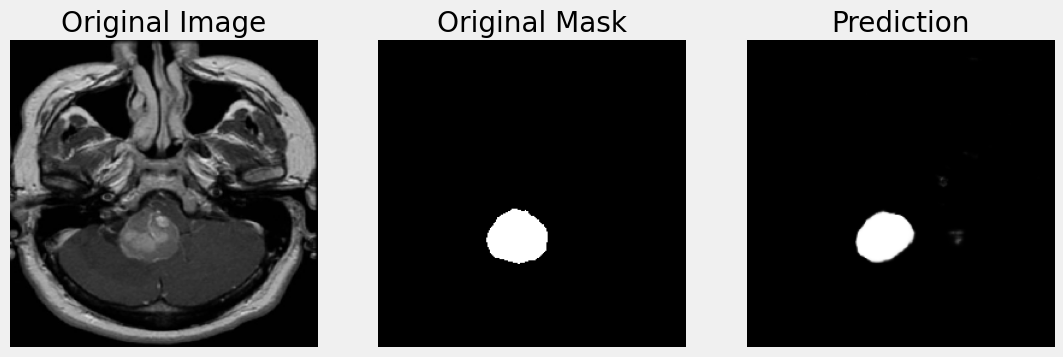

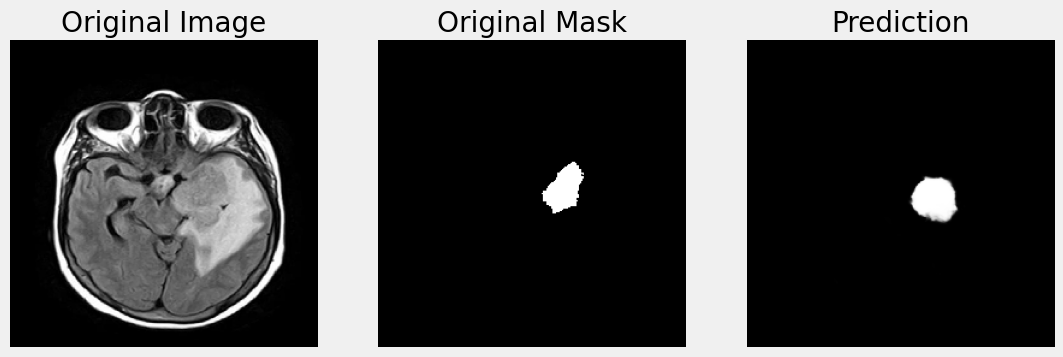

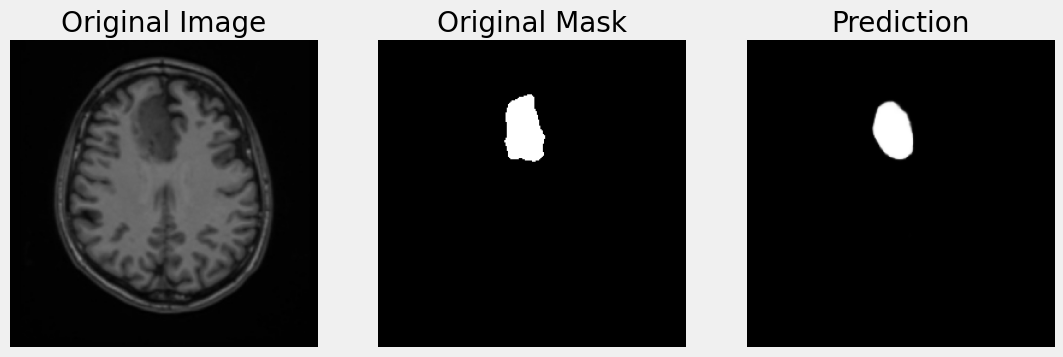

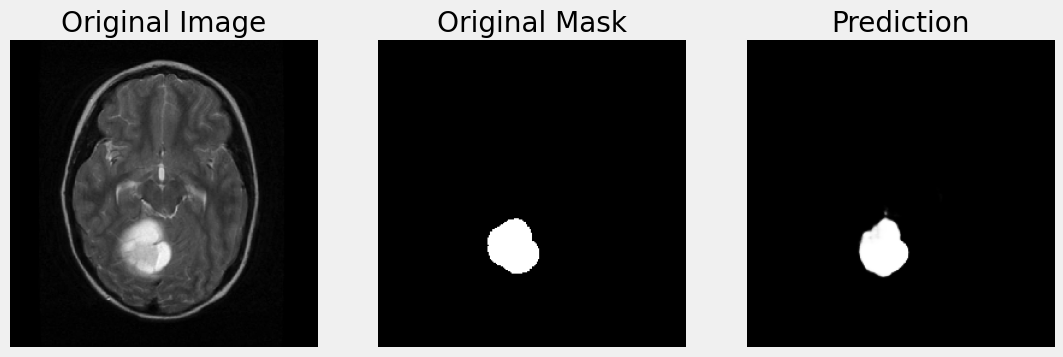

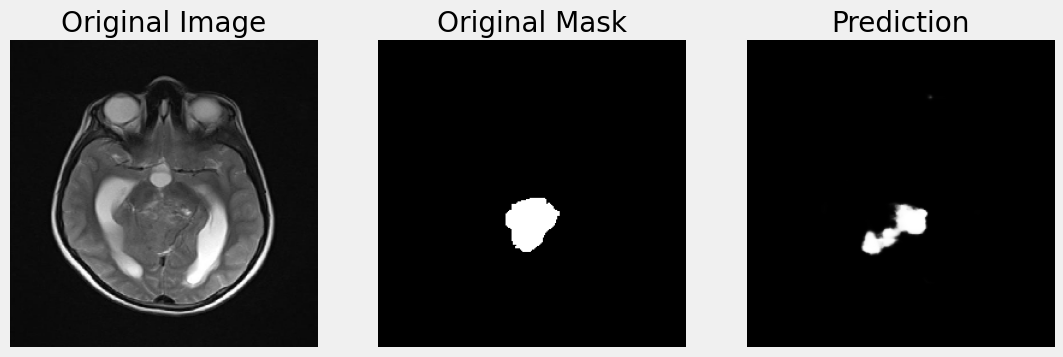

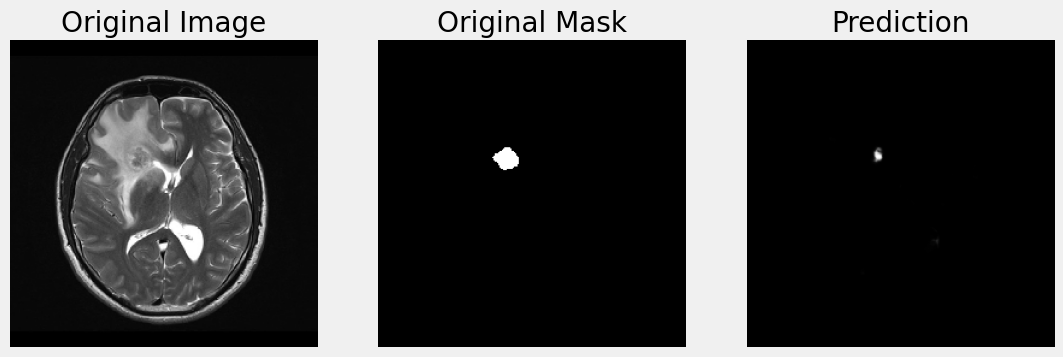

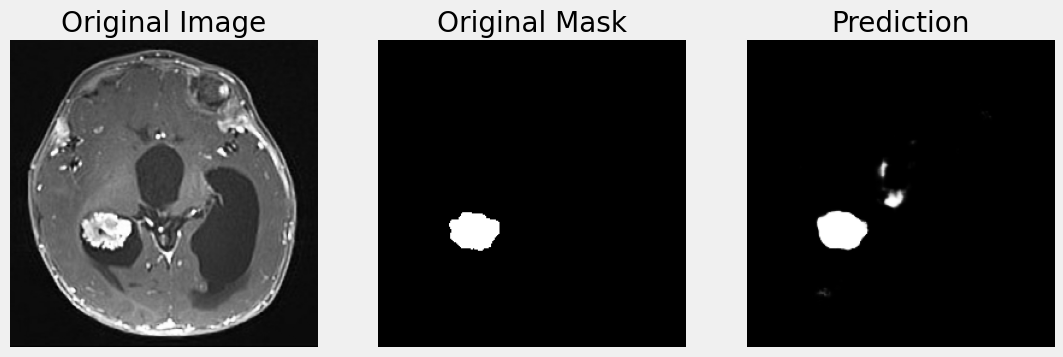

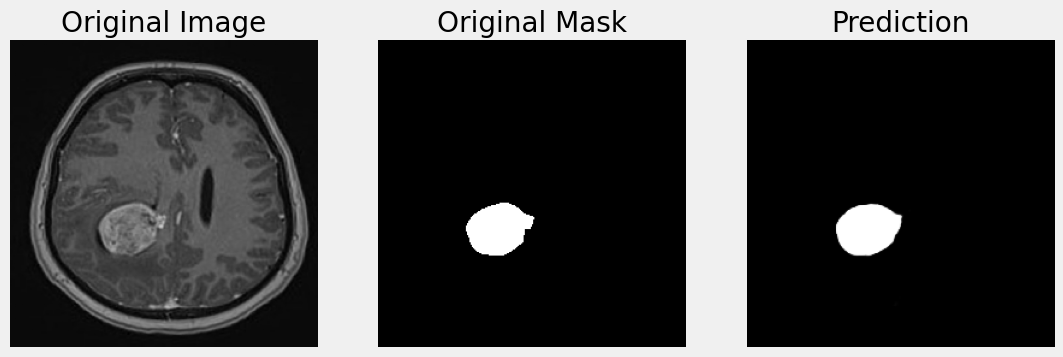

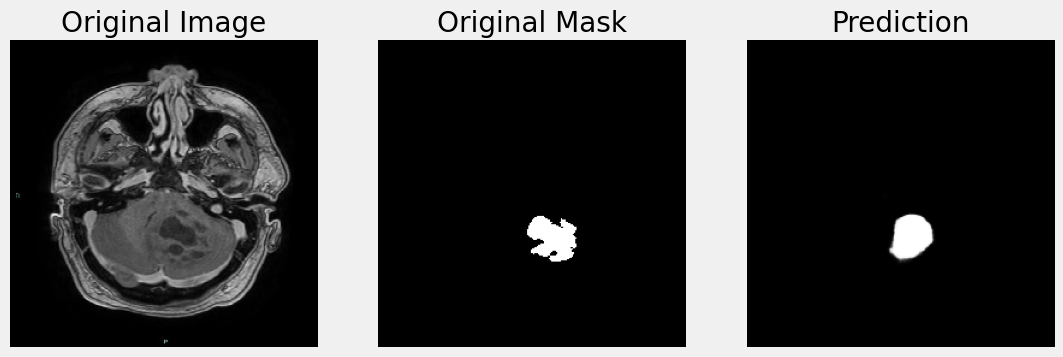

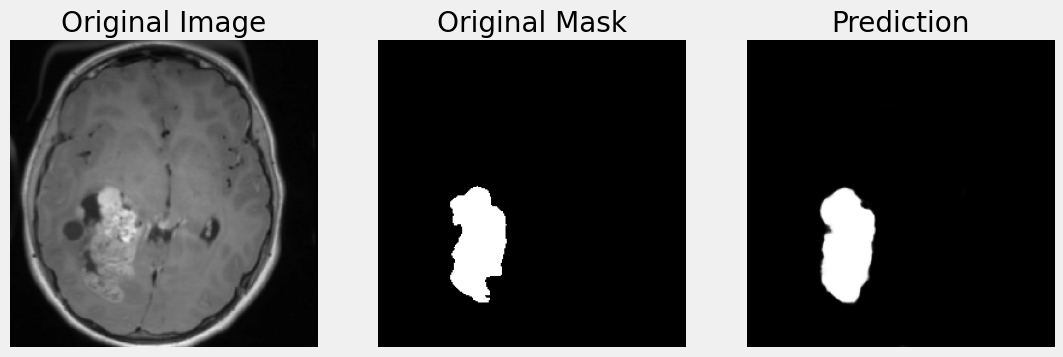

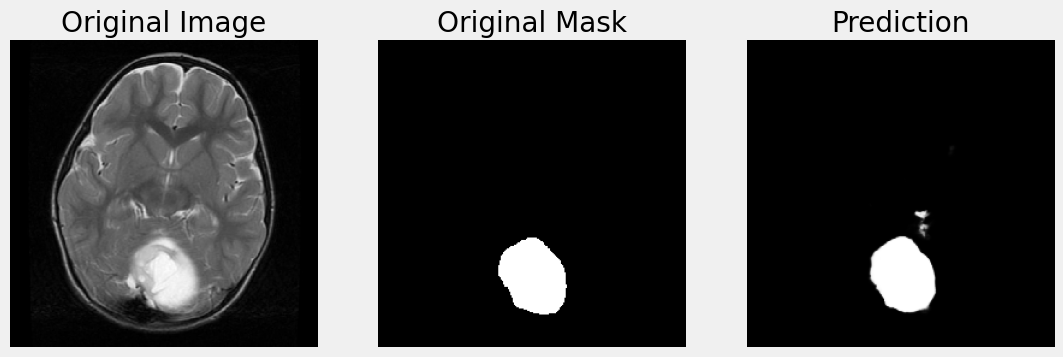

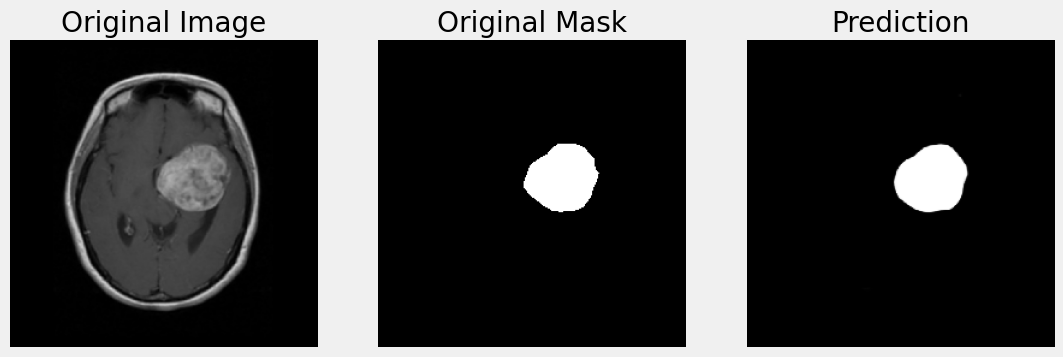

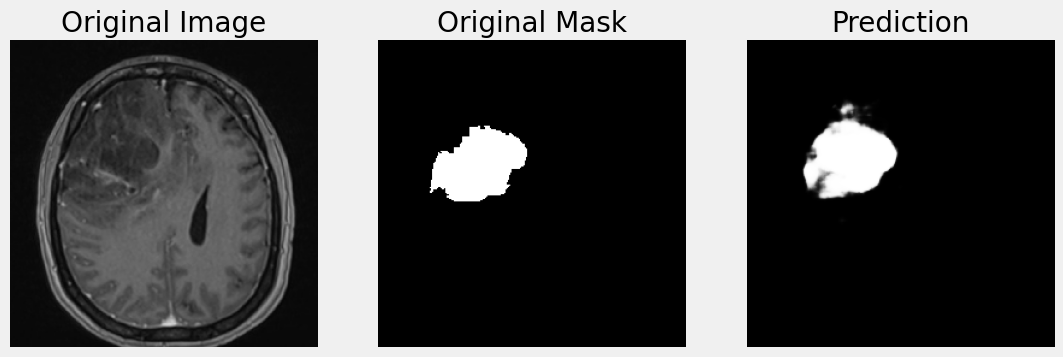

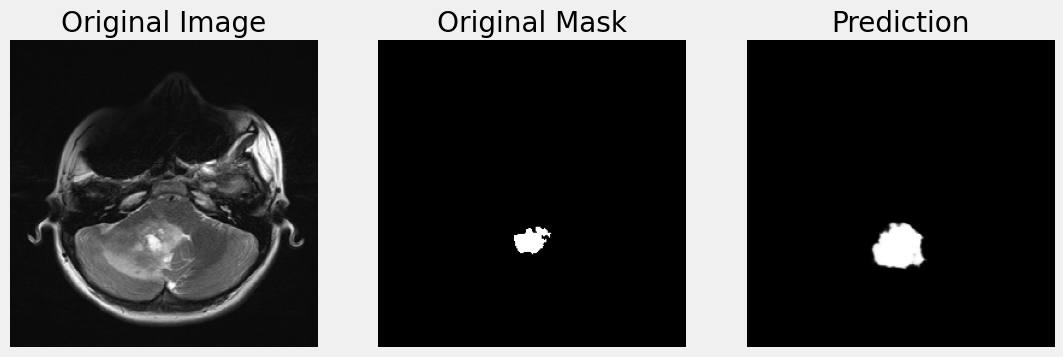

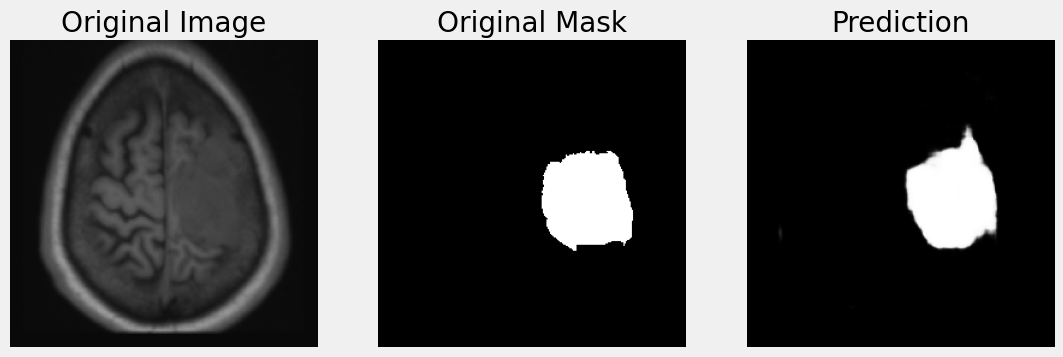

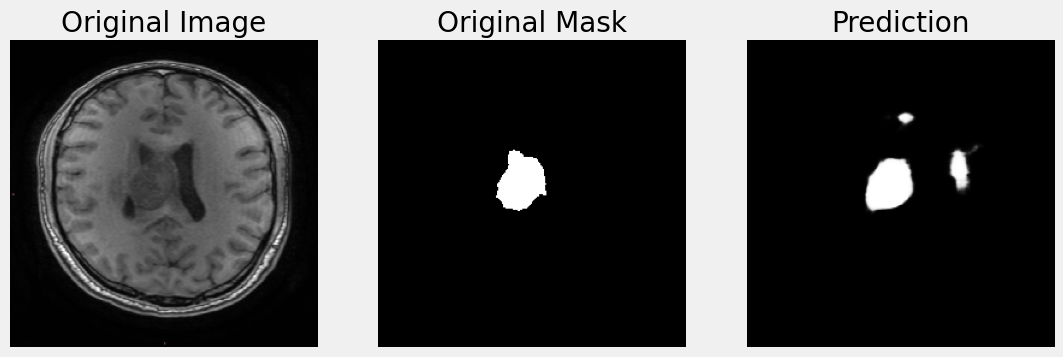

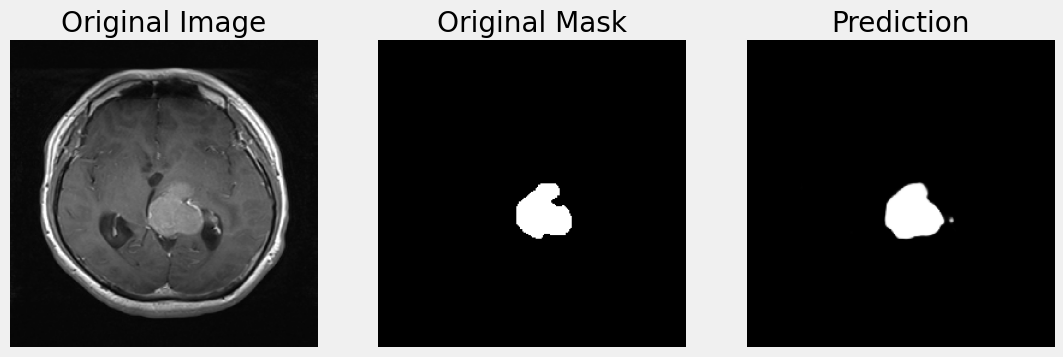

In [ ]:
print("Validation Images")
batch = next(val_gen)
preds = model.predict_on_batch(batch[0])
for _ in range(batch_size):
    plt.figure(figsize=(12, 12))

    plt.subplot(1, 3, 1)
    plt.imshow(batch[0][_])
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(batch[1][_], cmap="gray")
    plt.axis('off')
    plt.title('Original Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(preds[_], cmap="gray")
    plt.axis('off')
    plt.title('Prediction')

    plt.show()

Test Images


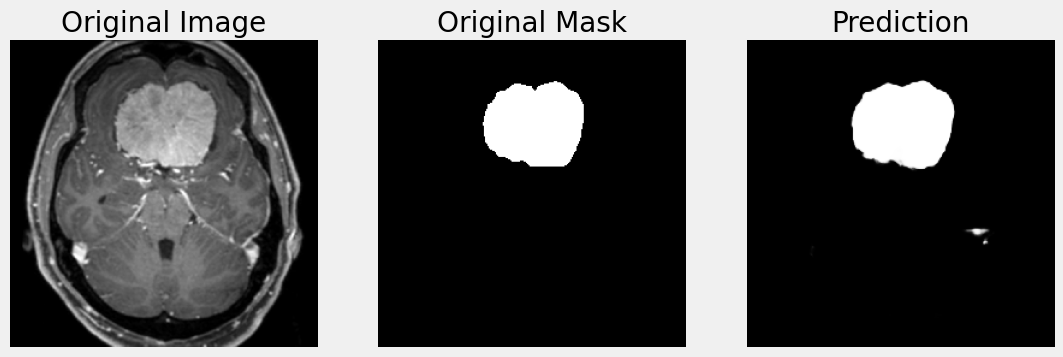

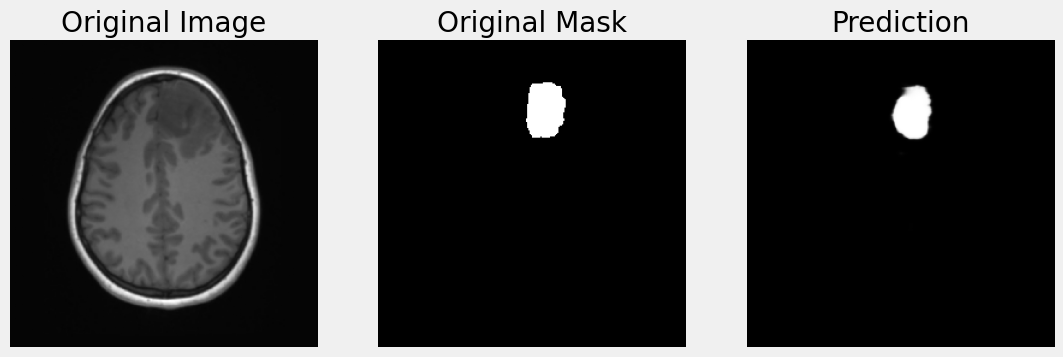

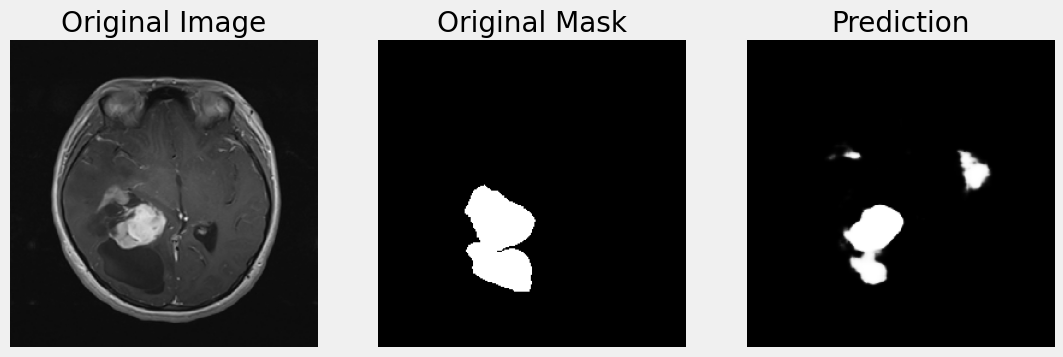

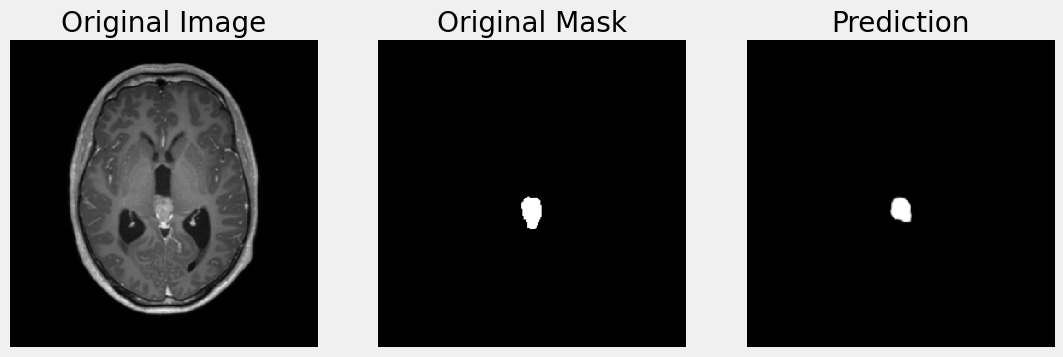

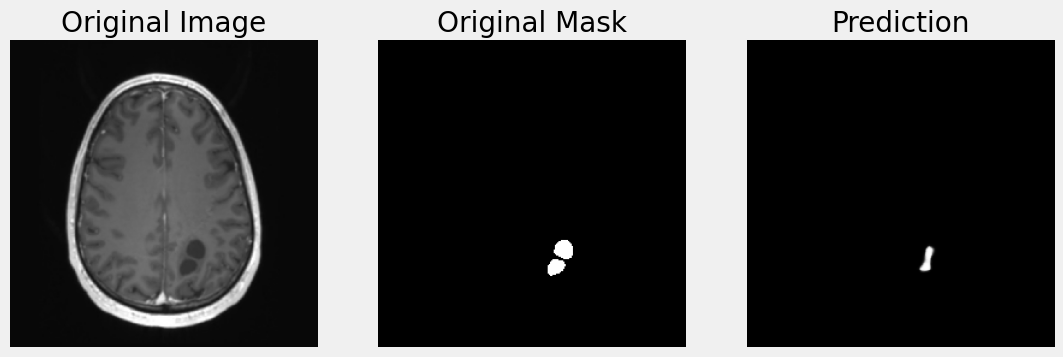

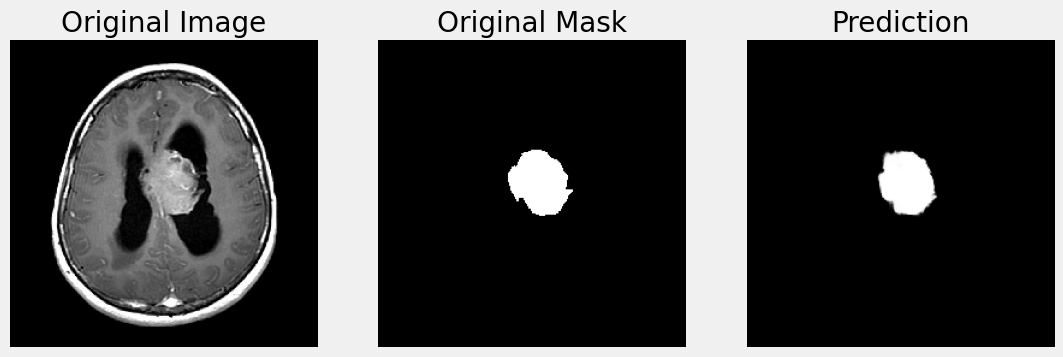

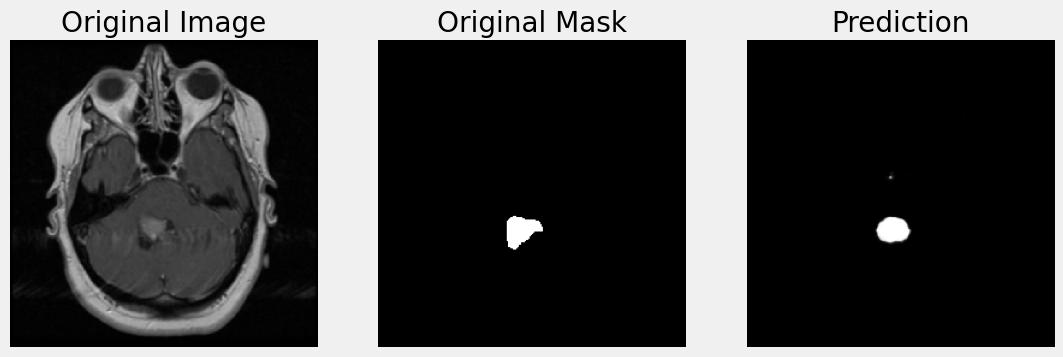

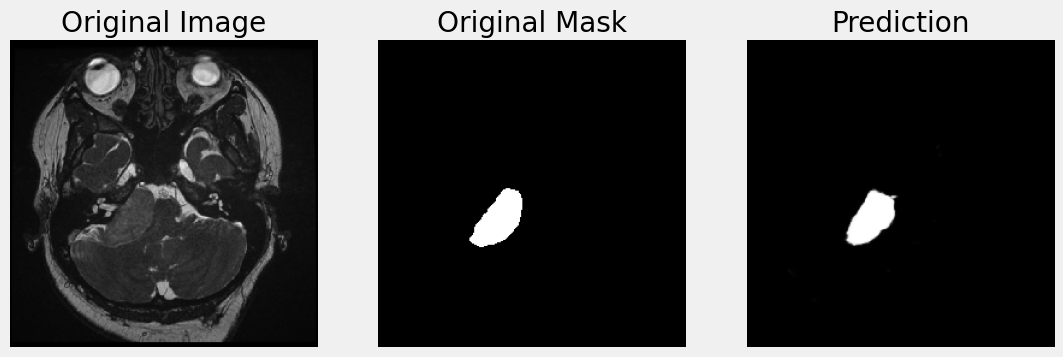

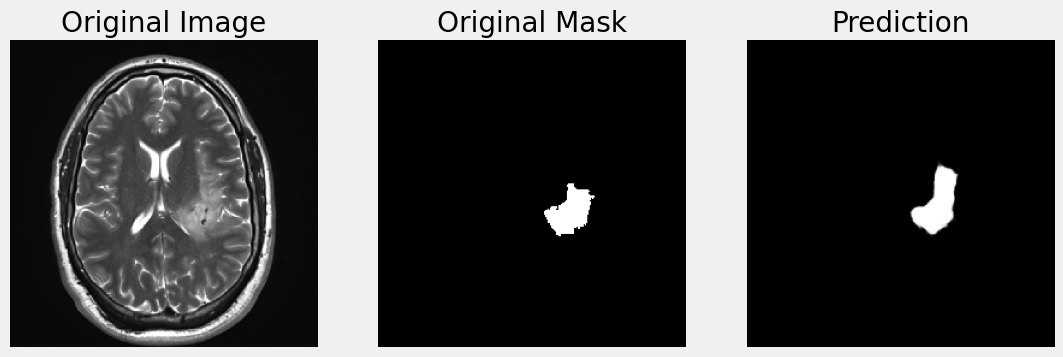

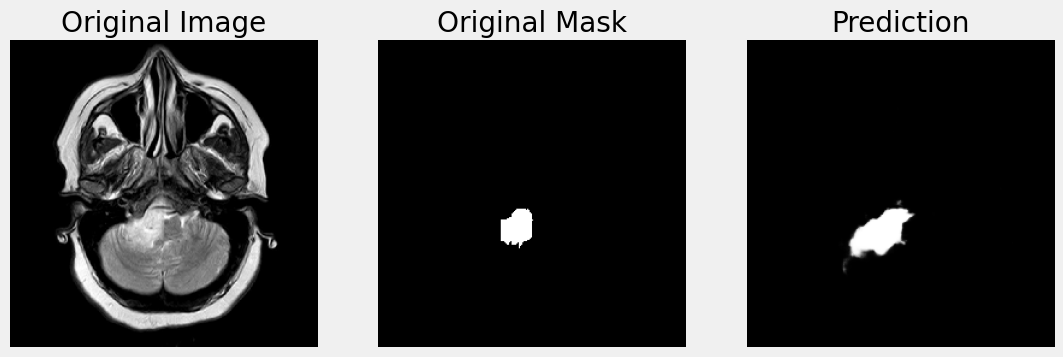

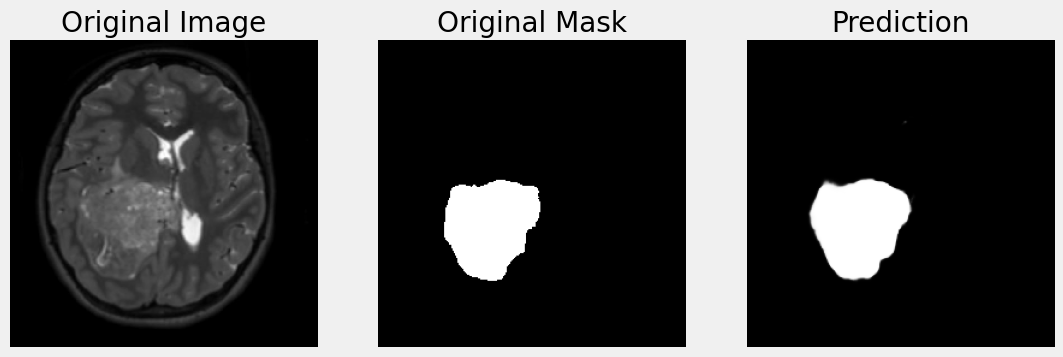

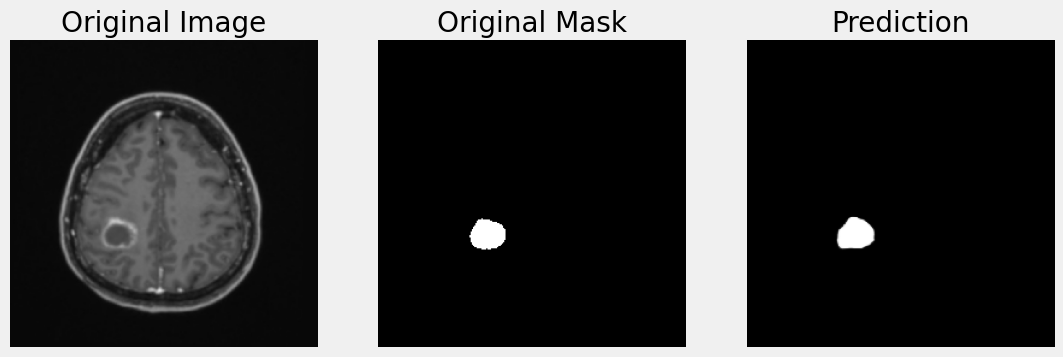

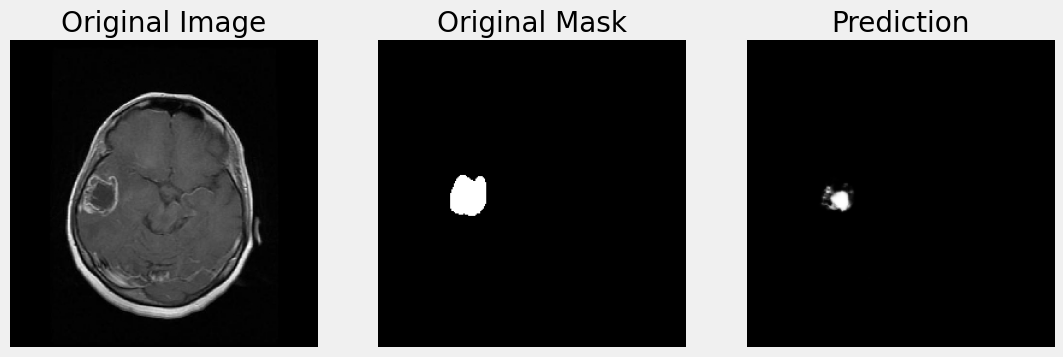

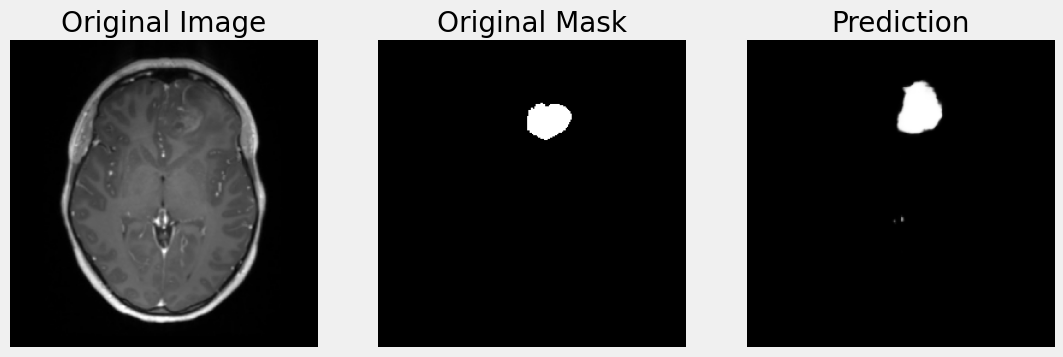

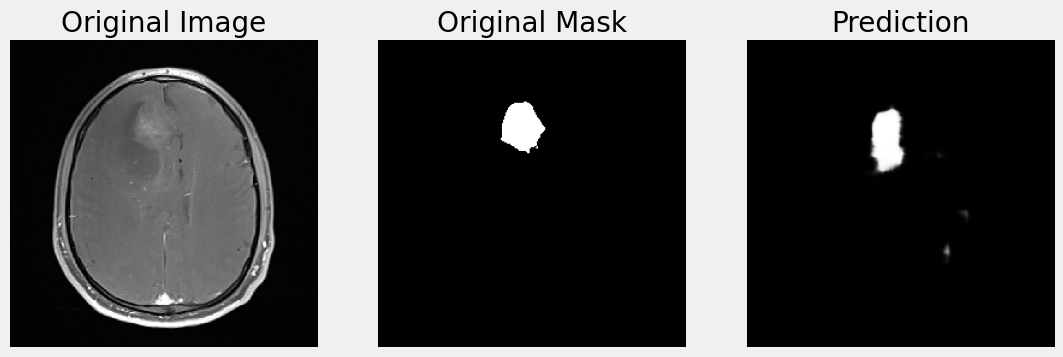

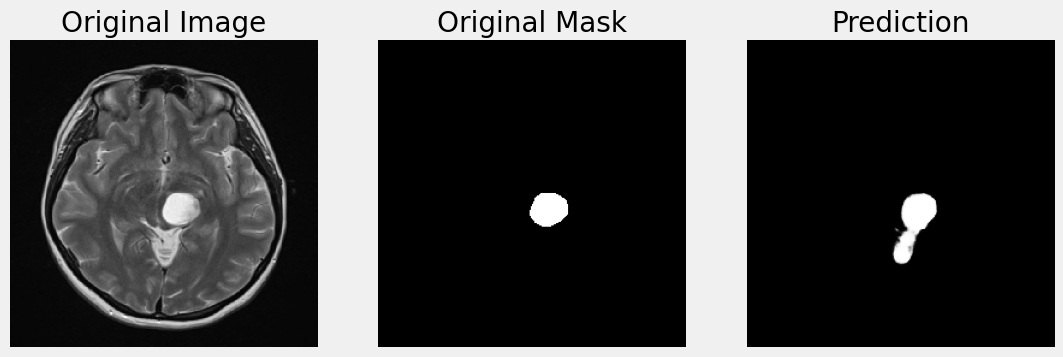

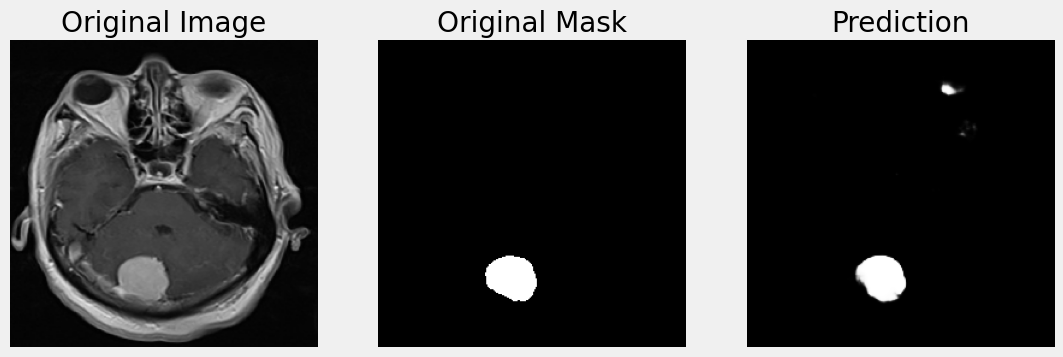

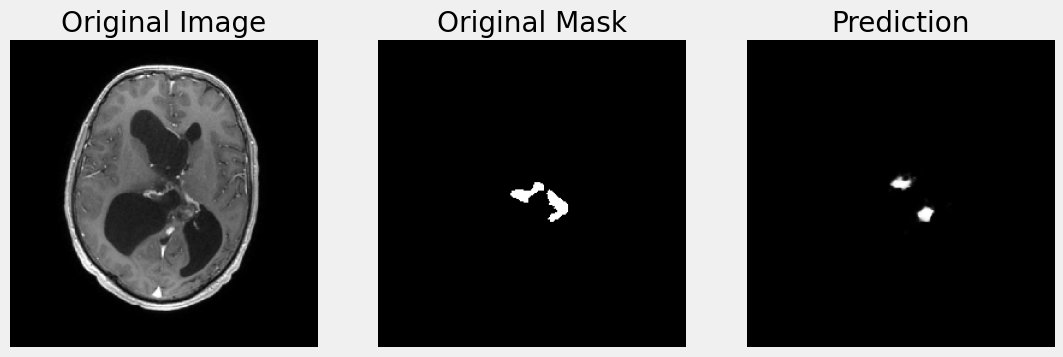

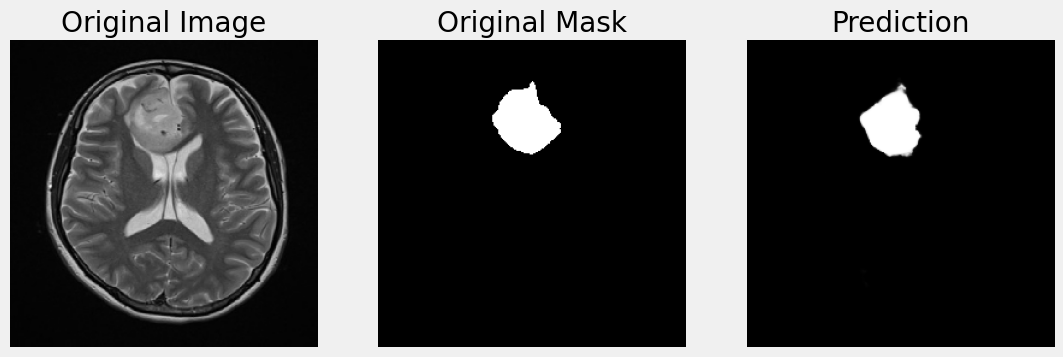

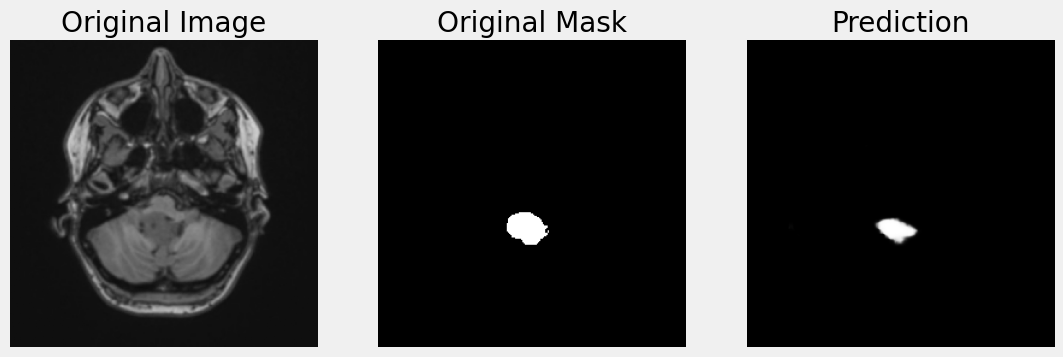

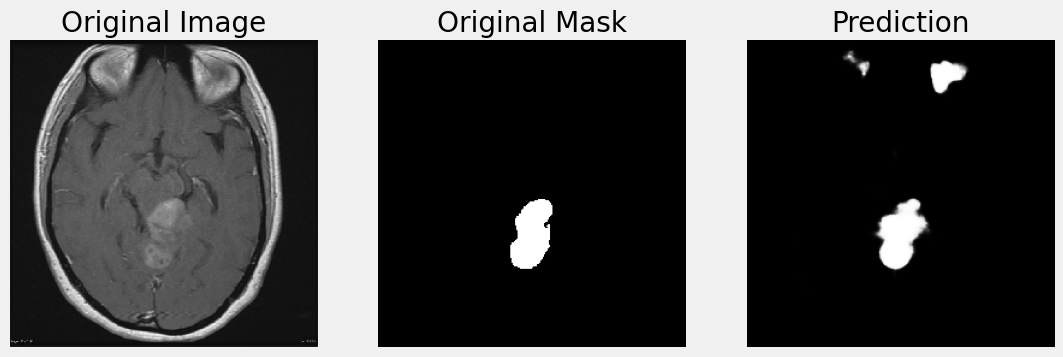

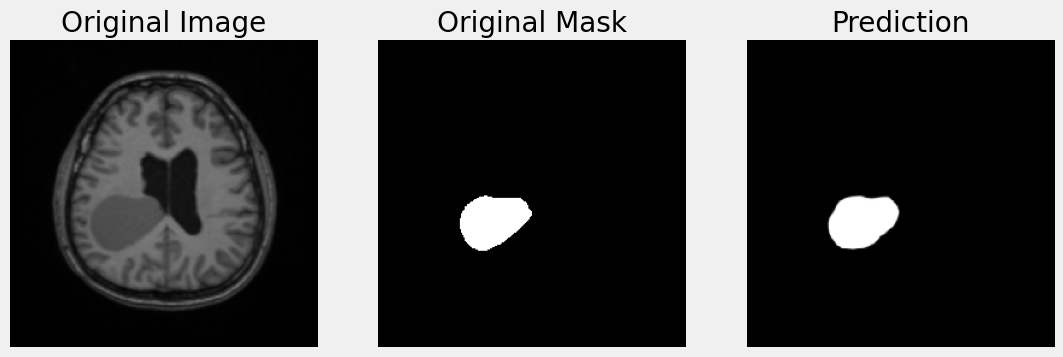

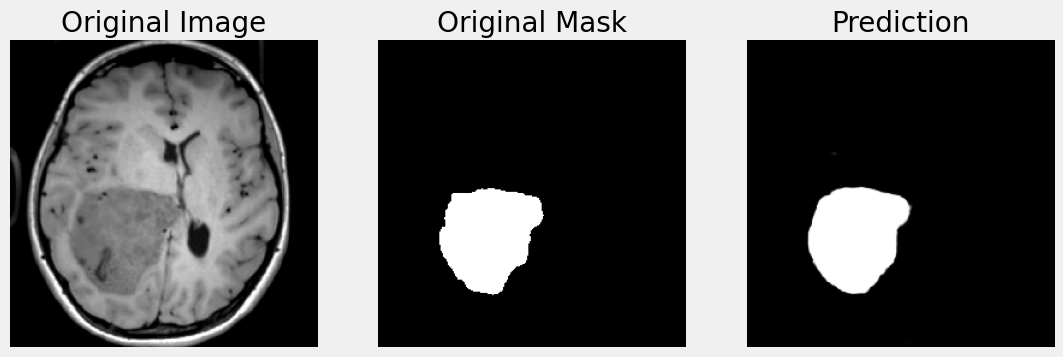

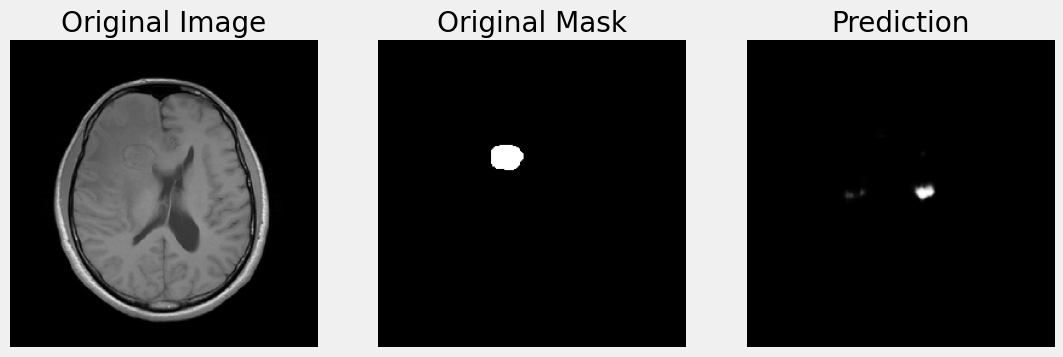

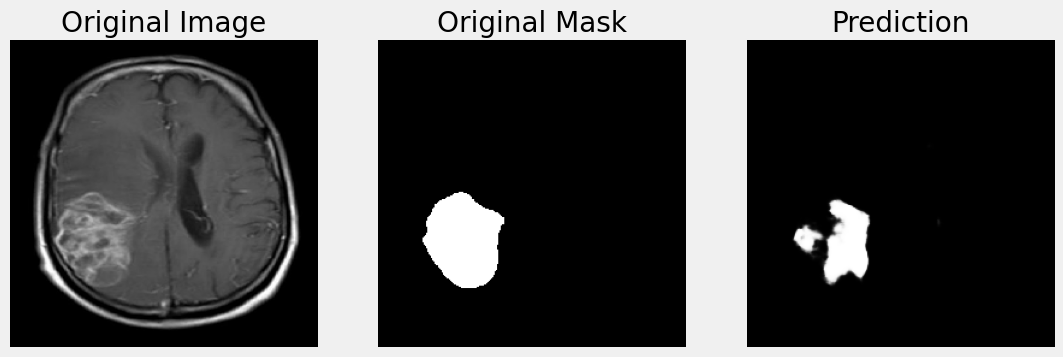

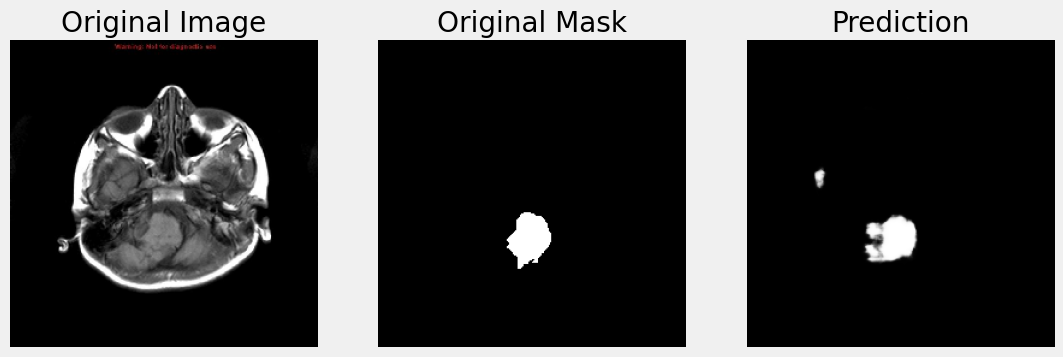

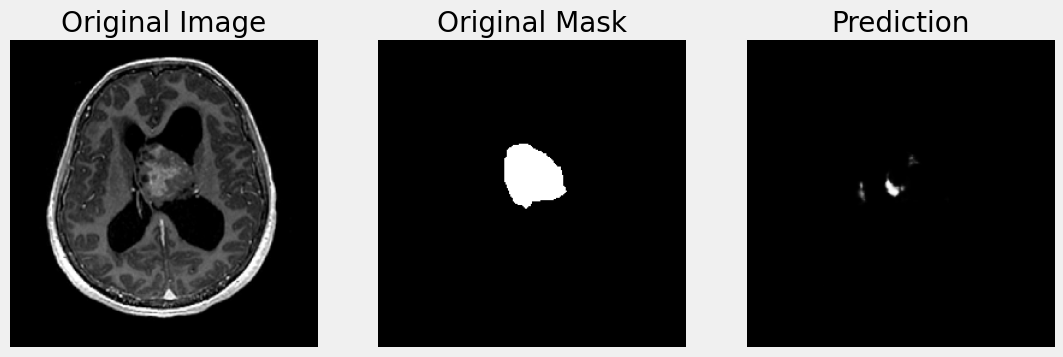

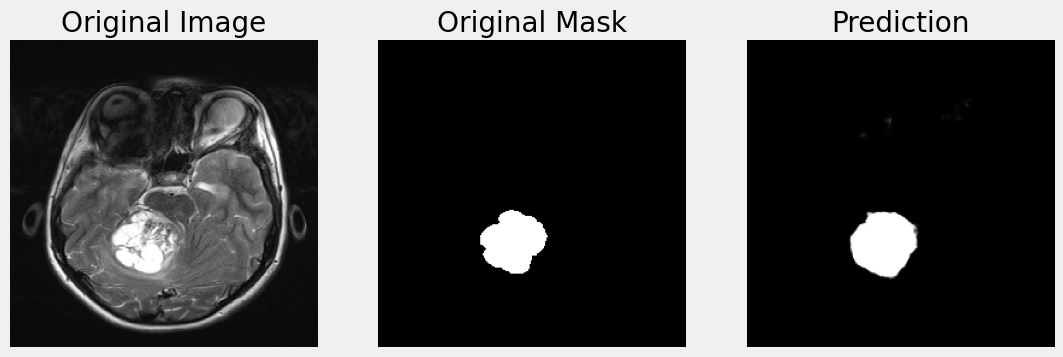

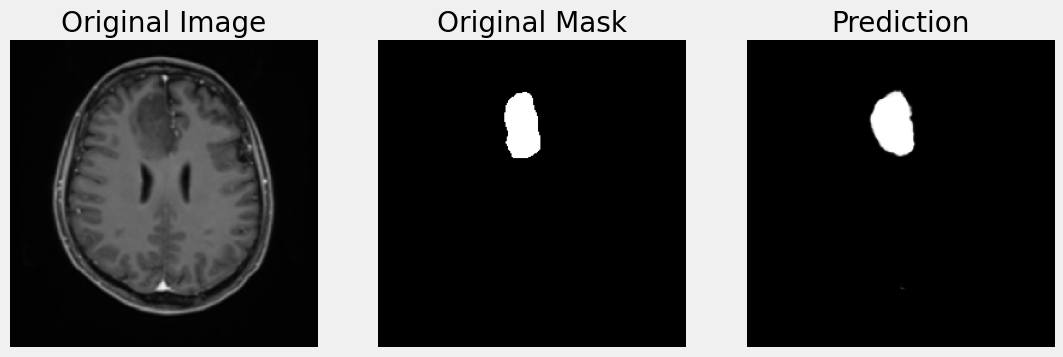

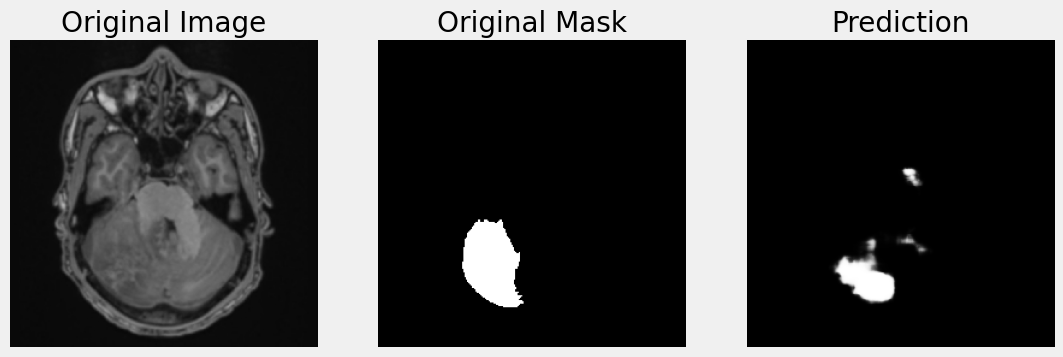

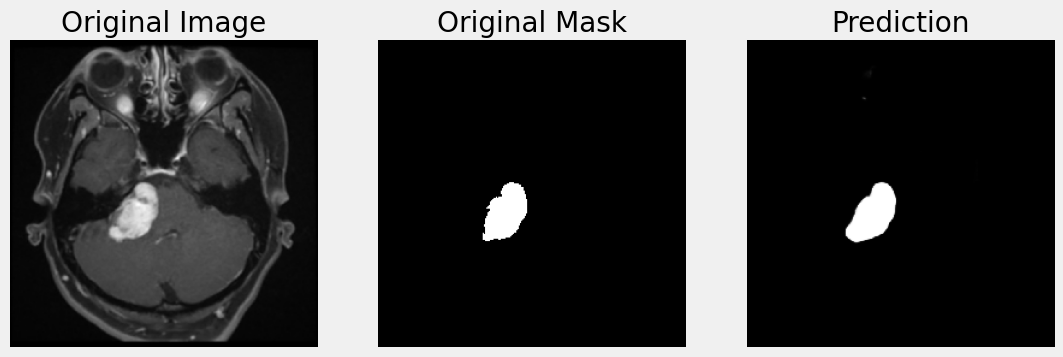

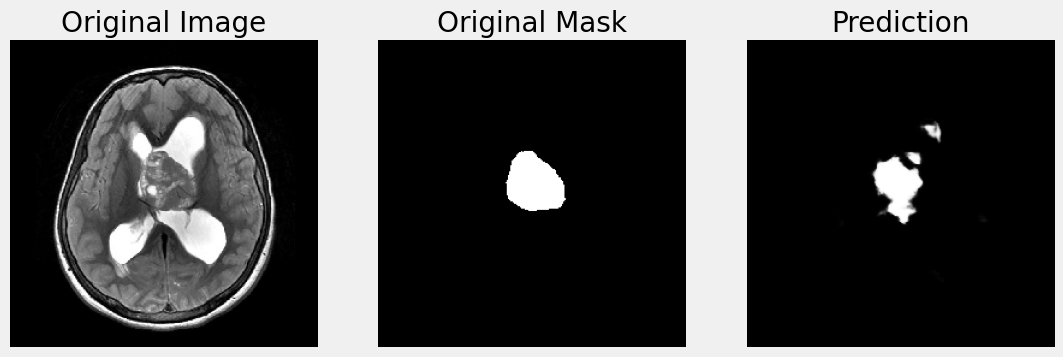

In [ ]:
print("Test Images")
batch = next(test_gen)
preds = model.predict_on_batch(batch[0])
for _ in range(batch_size):
    plt.figure(figsize=(12, 12))

    plt.subplot(1, 3, 1)
    plt.imshow(batch[0][_])
    plt.axis('off')
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(batch[1][_], cmap="gray")
    plt.axis('off')
    plt.title('Original Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(preds[_], cmap="gray")
    plt.axis('off')
    plt.title('Prediction')

    plt.show()

In [ ]:
shutil.copy(save_path, drive_path)

'/content/drive/MyDrive/TumorSegmentasyon/Clean-ResUNet-Adamax-32-bce-dice.h5'